In [2]:
#IMPORTS
import pandas as pd
import json
import matplotlib.pyplot as plt
import math as mt
import numpy as np
from matplotlib.patches import Circle
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv(r'C:\Users\mikey\Documents\Personal Stuff\Uni\08\prjct3\exoplanets.csv')
with open(r'C:\Users\mikey\Documents\Personal Stuff\Uni\08\prjct3\milky_way.json') as f:
    milky_way = json.load(f)
colours = ['#e6194b','#3cb44b','#ffe119','#4363d8','#f58231','#911eb4','#46f0f0','#f032e6','#bcf60c','#fabebe','#008080','#e6beff','#9a6324','#fffac8','#800000','#aaffc3','#808000','#ffd8b1','#000075','#808080']

In [4]:
def cap_masses(df):
    """
    Caps the values of the 'pl_bmasse' column in the DataFrame at 500 for planets 
    with masses greater than 500 Earth masses.

    Parameters:
    - df (DataFrame): A DataFrame that contains the column 'pl_bmasse'.

    Returns:
    - DataFrame: The input DataFrame with a new column 'capped_mass' containing 
                 capped planetary masses.
    """
    # Create a new column 'capped_mass' with values from 'pl_bmasse'
    df['capped_mass'] = df['pl_bmasse']

    # Cap the values at 500 for planets with mass > 500
    df.loc[df['capped_mass'] > 500, 'capped_mass'] = 500
    
    return df

cap_masses(df)

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,decstr,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag,rowupdate,pl_pubdate,releasedate,capped_mass
0,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,+17d47m35.71s,17.793252,93.1846,4.72307,2.282,4.44038,2014-07-23,2011-08,2014-07-23,500.00000
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,+17d47m35.71s,17.793252,93.1846,4.72307,2.282,4.44038,2014-05-14,2008-01,2014-05-14,500.00000
2,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,+17d47m35.71s,17.793252,93.1846,4.72307,2.282,4.44038,2023-09-19,2023-08,2023-09-19,500.00000
3,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,+71d49m26.19s,71.823943,125.3210,5.01300,1.939,4.56216,2018-09-04,2017-03,2018-09-06,500.00000
4,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,+71d49m26.19s,71.823943,125.3210,5.01300,1.939,4.56216,2018-04-25,2011-08,2014-07-23,500.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35916,ups And d,ups And,0,2,3,Radial Velocity,1999,Multiple Observatories,Published Confirmed,0,...,+41d24m13.73s,41.403815,13.4054,4.09565,2.859,3.98687,2014-08-21,2004-01,2014-08-21,500.00000
35917,ups Leo b,ups Leo,1,1,1,Radial Velocity,2021,Okayama Astrophysical Observatory,Published Confirmed,0,...,-00d49m24.83s,-0.823564,52.5973,4.30490,2.184,4.03040,2022-01-10,2021-12,2022-01-10,162.09249
35918,xi Aql b,xi Aql,0,1,1,Radial Velocity,2007,Okayama Astrophysical Observatory,Published Confirmed,0,...,+08d27m39.98s,8.461105,56.1858,4.70964,2.171,4.42501,2014-07-23,2011-08,2014-07-23,500.00000
35919,xi Aql b,xi Aql,0,1,1,Radial Velocity,2007,Okayama Astrophysical Observatory,Published Confirmed,0,...,+08d27m39.98s,8.461105,56.1858,4.70964,2.171,4.42501,2014-05-14,2008-06,2014-05-14,500.00000


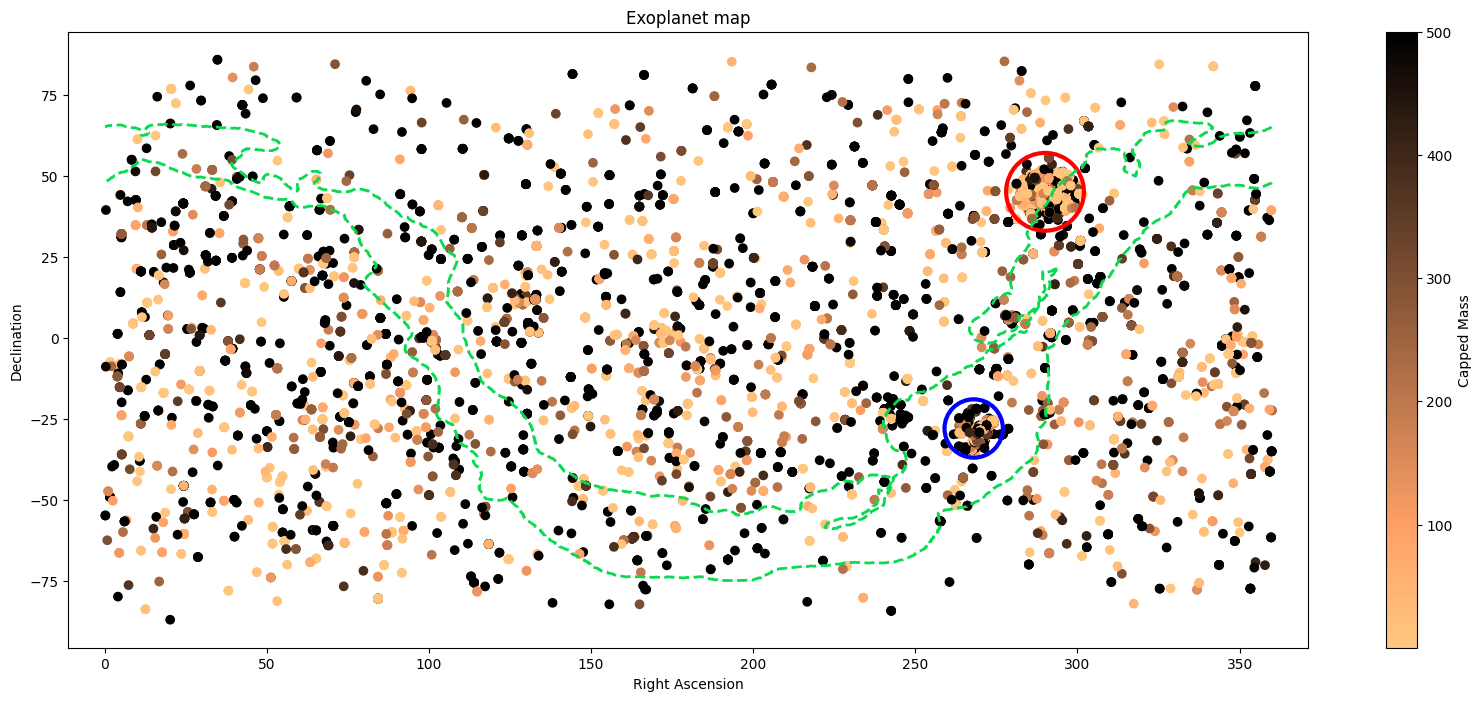

In [14]:
a = milky_way[0]
b = milky_way[1]

a1 = []
a2 = []
b1 = []
b2 = []
for i in a:
    a1.append(i[0])
    a2.append(i[1])
for k in b:
    b1.append(k[0])
    b2.append(k[1])





def overall_map(df):
    """
    Creates a scatter plot representing the celestial coordinates (Right Ascension 
    and Declination) of exoplanets, with marker color indicating capped masses. 
    
    Also displays in green dashed lines the outline of the Milky Way, and circles 
    (Red and Blue respectively) which show clusters of planets.

    Parameters:
    - df (DataFrame): A DataFrame that contains the columns 'ra','dec','capped_mass'.

    Returns:
    - None: The function generates and displays plot.
    """
    # Create the scatter plot
    plt.figure(figsize=(20, 8))
    plt.scatter(df['ra'], df['dec'], c=df['capped_mass'], cmap='copper_r')
    plt.colorbar(label='Capped Mass')

    plt.plot(a1, a2, linestyle='--', color='#0BDA51', linewidth=2)
    plt.plot(b1, b2, linestyle='--', color='#0BDA51', linewidth=2)
    
    # Set equal scales on both axes
    plt.axis('equal')
    
    # Set title
    plt.title('Exoplanet map')
    
    # Set labels for x and y axes
    plt.xlabel('Right Ascension')
    plt.ylabel('Declination')
    

    # Plot circles at specific coordinates
    c1 = (290,45)
    r1 = 12
    c2 = (268,-28)
    r2 = 9
    circle1 = Circle(c1,r1,edgecolor = "red",fill = 0,lw = 3)
    circle2 = Circle(c2,r2,edgecolor = "blue",fill = 0, lw = 3)

    # Show the plot
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)
    plt.show()

overall_map(df)

In [5]:
def analyse_systems(df):
    """
    Analyzes exoplanet systems by selecting necessary columns, renaming them, 
    removing duplicates, sorting by the number of stars and planets in descending 
    order, and resetting the index.

    Parameters:
    - df (DataFrame): A DataFrame that contains the columns 'hostname','sy_snum','sy_pnum'.

    Returns:
    - DataFrame: A DataFrame containing columns 'name', 'number of 
                 stars', and 'number of planets', sorted in descending order by 
                 the number of stars and planets.
    """
    # Selecting necessary columns
    systems_df = df[['hostname', 'sy_snum', 'sy_pnum']]
    
    # Renaming columns
    systems_df.columns = ['name', 'number of stars', 'number of planets']
    
    # Dropping duplicates
    systems_df = systems_df.drop_duplicates(subset='name')
    
    # Sorting by number of stars and number of planets
    systems_df = systems_df.sort_values(by=['number of stars', 'number of planets'], ascending=[False, False])
    
    # Resetting index
    systems_df = systems_df.reset_index(drop=True)
    
    return systems_df
systems = analyse_systems(df)

In [6]:
def analyse_facilities(df):
    """
    Analyzes facilities used for exoplanet discovery. Removes rows where the discovery 
    facility is 'Multiple Observatories' or 'Multiple Facilities', and grouping
    by discovery facility. The function assigns colors to each facility and sorts them 
    by count in descending order.

    Parameters:
    - df (DataFrame): A DataFrame that contains the columns 'disc_facility','ra','dec'.

    Returns:
    - DataFrame: A DataFrame that contains the columns 'name', 'count', 
    'min_ra', 'max_ra', 'min_dec', 'max_dec' (maximum Declination), 'ra_range', 
    'dec_range', and 'colour' sorted by count in descending order.
    """
    global colours
    
    # Filter out rows where disc_facility is 'Multiple Observatories' or 'Multiple Facilities'
    df_filtered = df[~df['disc_facility'].isin(['Multiple Observatories', 'Multiple Facilities'])]

    # Group by disc_facility
    grouped = df_filtered.groupby('disc_facility').agg(
        count=('disc_facility', 'size'),
        min_ra=('ra', 'min'),
        max_ra=('ra', 'max'),
        min_dec=('dec', 'min'),
        max_dec=('dec', 'max')
    ).reset_index()

    # Calculate ra_range and dec_range
    grouped['ra_range'] = grouped['max_ra'] - grouped['min_ra']
    grouped['dec_range'] = grouped['max_dec'] - grouped['min_dec']

    # Rename columns to match the required output
    grouped.rename(columns={'disc_facility': 'name'}, inplace=True)

    # Sort by count in descending order
    facilities = grouped.sort_values(by='count', ascending=False).reset_index(drop=True)

    # Assign a placeholder for 'colour' column
    facilities['colour'] = colours[-1]  # Default to the 20th colour
    num_facilities = len(facilities)
    for i in range(min(19, num_facilities)):
        facilities.at[i, 'colour'] = colours[i]

    return facilities

facilities = analyse_facilities(df)

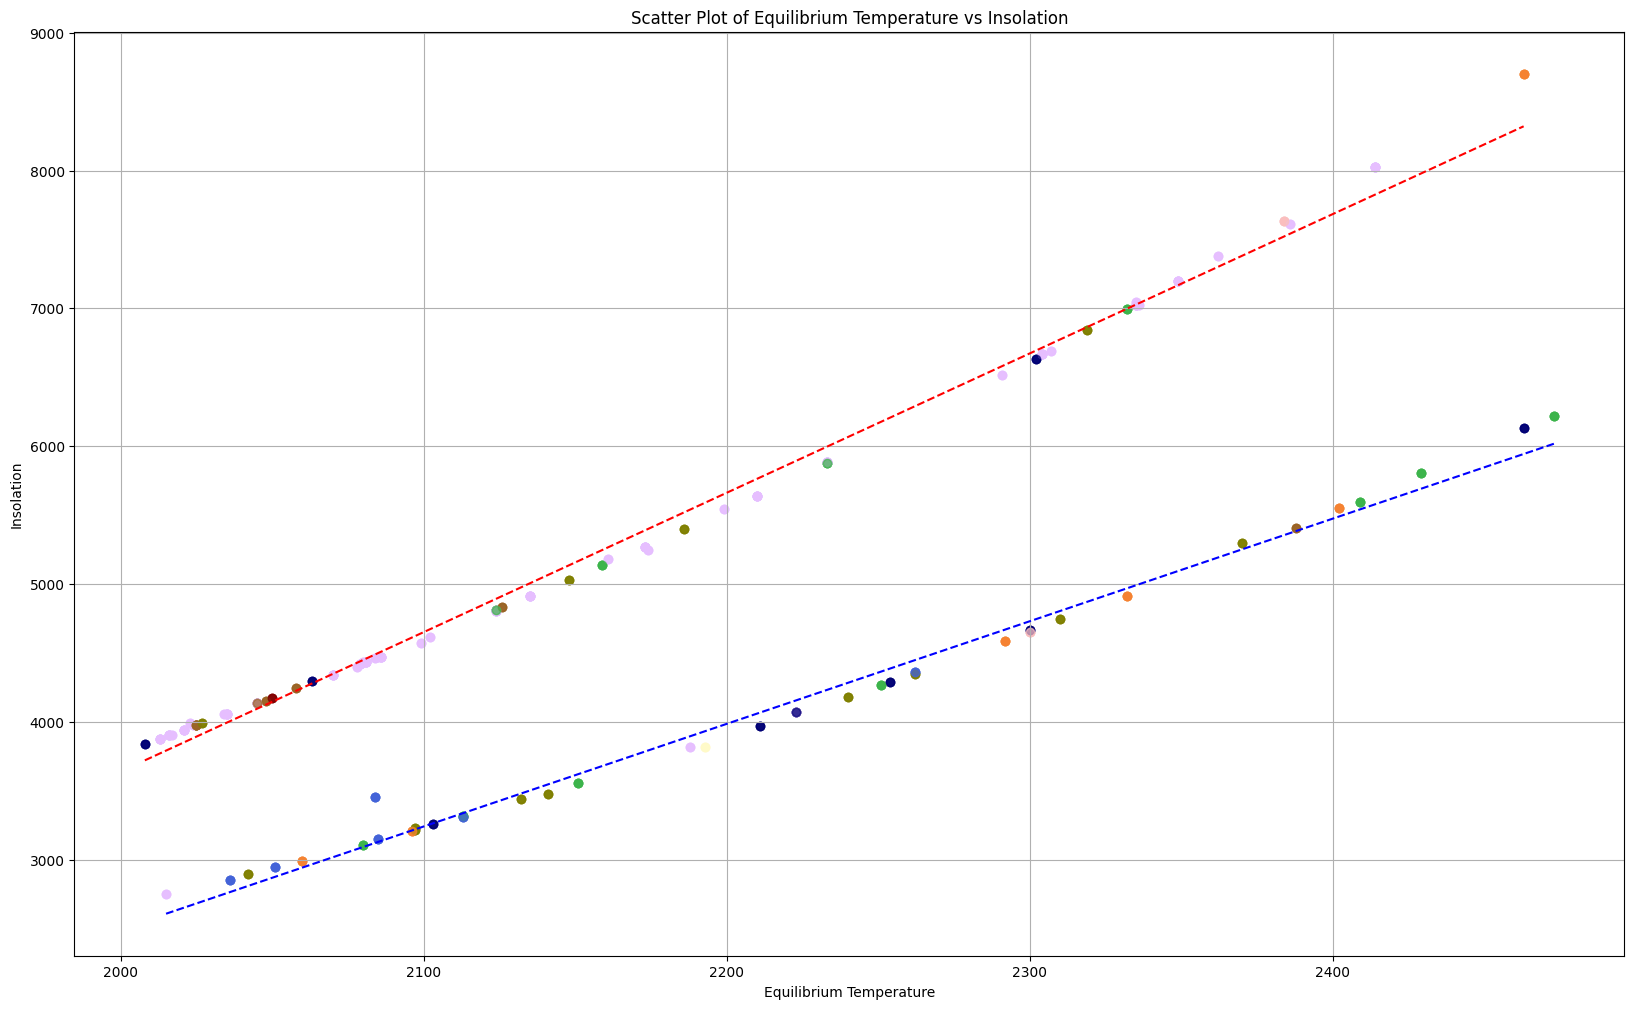

In [15]:
def show_insolation(df):
    """
    Displays a scatter plot of equilibrium temperature versus insolation for 
    exoplanets, with points colored based on the discovery facility. It also 
    performs linear regression on two subsets of the data divided by a specified 
    linear boundary and plots the resulting regression lines.

    Parameters:
    - df (DataFrame): A DataFrame that contains columns 'disc_facility', 'pl_eqt', and 
                      'pl_insol'.

    Returns:
    - None: The function generates and displays a scatter plot with linear 
            regression lines.
    """



    global colours


    # Remove the quotes around each colour code
    colours = [colour.strip("'") for colour in colours]

    # Map facilities to colours
    unique_facilities = df['disc_facility'].unique()
    facility_to_colour = {facility: colours[i % len(colours)] for i, facility in enumerate(unique_facilities)}

    # Add the colour column to the DataFrame
    df['colour'] = df['disc_facility'].map(facility_to_colour)



    df0 = df[['pl_eqt', 'pl_insol', 'colour']]

    # Filter rows based on equilibrium temperature
    df0 = df0[(df0['pl_eqt'] >= 2000) & (df0['pl_eqt'] <= 2500)]

    # Drop rows with missing data
    df0 = df0.dropna()




    plt.figure(figsize=(20, 12))
    for facility, colour in facility_to_colour.items():
        plt.scatter(df0[df0['colour'] == colour]['pl_eqt'], df0[df0['colour'] == colour]['pl_insol'], c=colour, alpha=0.7, label=facility)

    # Add labels and title
    plt.xlabel('Equilibrium Temperature')
    plt.ylabel('Insolation')
    plt.title('Scatter Plot of Equilibrium Temperature vs Insolation')


    slope = 10
    intercept = -17000


    df1 = pd.DataFrame(columns=['pl_eqt', 'pl_insol', 'color'])
    df2 = pd.DataFrame(columns=['pl_eqt', 'pl_insol', 'color'])

    # Iterate through df0 and classify points
    for index, row in df0.iterrows():
        x = row['pl_eqt']
        y = row['pl_insol']
        if y > (slope * x + intercept):
            df1 = pd.concat([df1, pd.DataFrame(row).transpose()], ignore_index=True)
        else:
            df2 = pd.concat([df2, pd.DataFrame(row).transpose()], ignore_index=True)

    # Reset index for df1 and df2
    df1.reset_index(drop=True, inplace=True)
    df2.reset_index(drop=True, inplace=True)


    def perform_linear_regression(df):
        X = df['pl_eqt'].values.reshape(-1, 1)
        y = df['pl_insol'].values
        model = LinearRegression()
        model.fit(X, y)
        return model

    # Perform linear regression on df1
    model_df1 = perform_linear_regression(df1)

    # Perform linear regression on df2
    model_df2 = perform_linear_regression(df2)

    
    # Plot regression line for df1
    slope1 = model_df1.coef_[0]
    intercept1 = model_df1.intercept_
    x_values1 = np.linspace(df1['pl_eqt'].min(), df1['pl_eqt'].max(), 100)
    y_values1 = slope1 * x_values1 + intercept1
    plt.plot(x_values1, y_values1, color='red', linestyle='--', label='Line: y = {}x + {}'.format(slope1, intercept1))

    # Plot regression line for df2
    slope2 = model_df2.coef_[0]
    intercept2 = model_df2.intercept_
    x_values2 = np.linspace(df2['pl_eqt'].min(), df2['pl_eqt'].max(), 100)
    y_values2 = slope2 * x_values2 + intercept2
    plt.plot(x_values2, y_values2, color='blue', linestyle='--', label='Line: y = {}x + {}'.format(slope2, intercept2))





    # Show plot
    plt.grid(True)
    plt.show()


show_insolation(df)

Question Analysis:

The three questions I have chosen to attempt to answer are:

Some facilities observe a fixed part of the sky, some of them observe the whole of the northern
hemisphere (where the declination is positive) or the whole of the southern hemisphere, and some of
them observe the whole sky. Which of these cases apply for the top twenty facilities?

Which are the most important facilities contributing records to the dataset? What methods did they
use, and in which years did they publish most of their results?

How many different discovery methods are there? How does this change if we ignore methods that
were used for less than 100 of the rows?


Starting with Question 1:

Some facilities observe a fixed part of the sky, some of them observe the whole of the northern
hemisphere (where the declination is positive) or the whole of the southern hemisphere, and some of
them observe the whole sky. Which of these cases apply for the top twenty facilities?

To first attempt this we use the follow function, which returns information on the top 20 most common facilities, showing their maximum, minimum, standard deviation and range for both Right Accension and Declination. 

Sites which have very low standard deviations for both declination and right accension will be most likely observing one spot in the sky. Those with a larger range and standard deviation, but with minimum and maximum declination that are both positive will be observing the northern hemisphere, and likewise if both are negative, they will be observing the southern hemisphere. Any remaining facilities will be observing a full range of the sky.



In [18]:
def analyse_facilities_ra_dec(df):
    """
    Analyzes RA and Dec data for each unique discovery facility and returns
    information on the range, standard deviation, maximum, and minimum values
    for Dec and RA for the 20 most common discovery facilities, split into
    four sections based on specific criteria.

    Parameters:
    - df (DataFrame): A DataFrame that contains the columns 'disc_facility',
                      'ra', and 'dec'.

    Returns:
    - dict: A dictionary containing four DataFrames:
            'low_std': Facilities with both RA and Dec standard deviations less than 5.
            'positive_dec': Facilities with both Dec max and min positive.
            'negative_dec': Facilities with both Dec max and min negative.
            'remaining': Facilities not in the above three categories.
    """
    # Filter out rows with missing data in 'disc_facility', 'ra', or 'dec'
    df = df.dropna(subset=['disc_facility', 'ra', 'dec'])

    # Get the 20 most common discovery facilities
    top_facilities = df['disc_facility'].value_counts().nlargest(20).index

    # Filter the DataFrame to include only rows with the top 20 facilities
    df_top = df[df['disc_facility'].isin(top_facilities)]

    # Group by 'disc_facility' and calculate the required statistics
    grouped = df_top.groupby('disc_facility').agg(
        ra_range=('ra', lambda x: x.max() - x.min()),
        ra_std=('ra', 'std'),
        ra_min=('ra', 'min'),
        ra_max=('ra', 'max'),
        dec_range=('dec', lambda x: x.max() - x.min()),
        dec_std=('dec', 'std'),
        dec_min=('dec', 'min'),
        dec_max=('dec', 'max')
    ).reset_index()

    # Rename the 'disc_facility' column to 'facility'
    grouped.rename(columns={'disc_facility': 'facility'}, inplace=True)

    # Split the data into four sections based on the criteria
    low_std = grouped[(grouped['ra_std'] < 5) & (grouped['dec_std'] < 5)]
    remaining = grouped[~grouped['facility'].isin(low_std['facility'])]
    
    positive_dec = remaining[(remaining['dec_min'] > 0) & (remaining['dec_max'] > 0)]
    remaining = remaining[~remaining['facility'].isin(positive_dec['facility'])]

    negative_dec = remaining[(remaining['dec_min'] < 0) & (remaining['dec_max'] < 0)]
    remaining = remaining[~remaining['facility'].isin(negative_dec['facility'])]

    # Return the results in a dictionary
    return {
        'low_std': low_std,
        'positive_dec': positive_dec,
        'negative_dec': negative_dec,
        'remaining': remaining
    }



result = analyse_facilities_ra_dec(df)
print("Low Std Deviation Facilities:\n", result['low_std'])
print("Positive Dec Facilities:\n", result['positive_dec'])
print("Negative Dec Facilities:\n", result['negative_dec'])
print("Remaining Facilities:\n", result['remaining'])

Low Std Deviation Facilities:
    facility   ra_range    ra_std      ra_min      ra_max  dec_range   dec_std  \
6    KMTNet  11.482000  2.291395  262.840125  274.322125  13.804792  3.029426   
7    Kepler  21.514150  4.812583  280.206628  301.720777  15.571761  3.573640   
10      MOA  10.754758  1.798897  261.792500  272.547258   9.660772  2.042476   

      dec_min    dec_max  
6  -35.700331 -21.895539  
7   36.577344  52.149105  
10 -35.005411 -25.344639  
Positive Dec Facilities:
                       facility    ra_range      ra_std      ra_min  \
4   Haute-Provence Observatory  333.199181  100.633732   21.303381   
17                        TrES   37.192835   11.495860  268.029111   

        ra_max  dec_range    dec_std    dec_min    dec_max  
4   354.502562  80.630426  21.524211   0.408561  81.038987  
17  305.221945  22.816367   7.637838  36.632536  59.448903  
Negative Dec Facilities:
                       facility    ra_range      ra_std      ra_min  \
0   Anglo-Australian

As we can see from the above data, we can categorise the facilities into four types:

Those which observe a singular point (Below 5 standard deviation of both declination and right accension): KMTNet, Kepler, MOA.

Those which observe the northern hemisphere as a whole or partially, but not in a singular spot: Huate-Province observatory, TrES.

Those which observe the southern hemisphere as a whole or partially, but not in a singular spot: Angolo-Australian Telescope, HATSouth, OGLE.

And all remaining in the top 20 observe both hemispheres, and not just a singular spot: CoRoT, HATNet, K2, La Silla Observatory, Lick Observatory, Multiple Observatories, Okayama Astrophysical Observatory, Paranal Observatory, SuperWASP, SuperWASP-South, Transiting Exoplanet Survey Satellite (TESS), W. M. Keck Observatory.

We must comment that some of these findings may be slightly misleading. I chose an arbitrary value for the maximum standard deviation allowed to be observing a single spot (5), this may be too large or too small, however the nearest observatory to making the single spot list was TrES, which has values of 7.6 and 11.5 (to 1 decimal place) respectively, so I am quite comfortable with these results being correct.

Question 2:

Which are the most important facilities contributing records to the dataset? What methods did they
use, and in which years did they publish most of their results?

We can use another function, defined below, to analyse the original dataframe and do some statistical analysis on the observation methods and date of observation.

In [20]:
def facilityanalysis2(df):
    """
    Analyzes the frequency of discovery facilities, providing information on the top 20
    facilities, including the mean and standard deviation of discovery years and the
    total number of instances and percentage of each discovery method for each facility.

    Parameters:
    - df (DataFrame): A DataFrame that contains columns 'disc_facility',
                      'disc_year', and 'discoverymethod'.

    Returns:
    - dict: A dictionary with two keys:
            'top_facilities': A list of the top 20 discovery facilities.
            'facility_info': A DataFrame containing the following columns:
                             'facility', 'count', 'mean_disc_year', 'std_disc_year',
                             'discovery_method', 'method_count', 'method_percentage'.
    """
    # Filter out rows with missing data in 'disc_facility', 'disc_year', or 'discoverymethod'
    df = df.dropna(subset=['disc_facility', 'disc_year', 'discoverymethod'])

    # Get the top 20 most frequent discovery facilities
    top_facilities = df['disc_facility'].value_counts().nlargest(20).index.tolist()

    # Filter the DataFrame to include only rows with the top 20 facilities
    df_top = df[df['disc_facility'].isin(top_facilities)]

    # Group by 'disc_facility' and calculate required statistics for 'disc_year'
    facility_year_stats = df_top.groupby('disc_facility').agg(
        count=('disc_facility', 'size'),
        mean_disc_year=('disc_year', 'mean'),
        std_disc_year=('disc_year', 'std')
    ).reset_index()

    # Rename 'disc_facility' column to 'facility' for consistency
    facility_year_stats.rename(columns={'disc_facility': 'facility'}, inplace=True)

    # Initialize a list to store discovery method information
    method_info_list = []

    # Iterate through each facility in the top 20 facilities
    for facility in top_facilities:
        # Filter data for the current facility
        facility_data = df_top[df_top['disc_facility'] == facility]
        
        # Calculate discovery method counts and percentages
        method_counts = facility_data['discoverymethod'].value_counts()
        total_count = method_counts.sum()
        method_percentages = (method_counts / total_count) * 100
        
        # Create a DataFrame for the method information
        method_info = pd.DataFrame({
            'facility': facility,
            'discovery_method': method_counts.index,
            'method_count': method_counts.values,
            'method_percentage': method_percentages.values
        })
        
        # Append to the list
        method_info_list.append(method_info)
    
    # Concatenate all method info DataFrames into a single DataFrame
    method_info_df = pd.concat(method_info_list, ignore_index=True)

    # Merge the facility year stats with the method info DataFrame
    facility_info_df = method_info_df.merge(facility_year_stats, on='facility')

    return {
        'top_facilities': top_facilities,
        'facility_info': facility_info_df
    }


result = facilityanalysis2(df)
print("Top Facilities:\n", result['top_facilities'])
print("Facility Info:\n", result['facility_info'])

Top Facilities:
 ['Kepler', 'K2', 'Transiting Exoplanet Survey Satellite (TESS)', 'SuperWASP', 'W. M. Keck Observatory', 'La Silla Observatory', 'HATNet', 'Multiple Observatories', 'OGLE', 'HATSouth', 'KMTNet', 'Haute-Provence Observatory', 'SuperWASP-South', 'Lick Observatory', 'CoRoT', 'Anglo-Australian Telescope', 'Paranal Observatory', 'MOA', 'TrES', 'Okayama Astrophysical Observatory']
Facility Info:
                                         facility  \
0                                         Kepler   
1                                         Kepler   
2                                         Kepler   
3                                         Kepler   
4                                         Kepler   
5                                             K2   
6                                             K2   
7   Transiting Exoplanet Survey Satellite (TESS)   
8   Transiting Exoplanet Survey Satellite (TESS)   
9   Transiting Exoplanet Survey Satellite (TESS)   
10                

From this, we can see the top observatory by a considerable way is Kepler, followed by K2, TESS, SuperWASP and W.M. Keck Observatory.

We can see Transit is also by far the most popular method for the top 4 facilities, making up 99.4%, 99.9%, 99.6%, and 99.8% of observations respectively. Only W.M. Keck is different, using Radial Velocity for 97.5% of it's observations. Every other observation method is effectively negligible, making up less that 1% of observations combined for the top 5. Kepler also completely dominates, observing over 13 times as many planets as the second facility.

We can also see most discoveries are made in the 2010's, with for the top 5 facilities the mean year of discovery being 2015, 2017, 2021, 2011, 2007. I believe this shows an improvement in imaging technology, with the third most detections coming from an observatory which averaged 2021, and implies we will continue to see more discoveries at a higher rate as time passes.

Question 3:

How many different discovery methods are there? How does this change if we ignore methods that
were used for less than 100 of the rows?

Once again, we use a python function to extract and analyse the sections of the data set we need to look at.

In [21]:
def analyse_discovery_methods(df):
    """
    Analyzes the discovery methods in the given DataFrame. Outputs the discovery methods
    in order of most to least common, with the percentage of total discoveries that used
    each method. Also outputs the same analysis excluding methods used less than 100 times.

    Parameters:
    - df (DataFrame): A DataFrama that contains the column 'discoverymethod'.

    Returns:
    - dict: A dictionary with two keys:
            'all_methods': A DataFrame with all discovery methods, their counts, and percentages.
            'filtered_methods': A DataFrame with discovery methods used at least 100 times, their counts, and percentages.
    """
    # Calculate the total number of discoveries
    total_discoveries = len(df)

    # Group by 'discoverymethod' and count the occurrences
    method_counts = df['discoverymethod'].value_counts().reset_index()
    method_counts.columns = ['discoverymethod', 'count']

    # Calculate percentages
    method_counts['percentage'] = (method_counts['count'] / total_discoveries) * 100

    # Filter out methods used less than 100 times
    filtered_methods = method_counts[method_counts['count'] >= 100]

    # Calculate the total number of discoveries in the filtered group
    total_filtered_discoveries = filtered_methods['count'].sum()

    # Recalculate percentages for the filtered group
    filtered_methods['percentage'] = (filtered_methods['count'] / total_filtered_discoveries) * 100

    # Return the results as a dictionary
    return {
        'all_methods': method_counts,
        'filtered_methods': filtered_methods
    }


result = analyse_discovery_methods(df)
print("All Methods:\n", result['all_methods'])
print("Filtered Methods:\n", result['filtered_methods'])

All Methods:
                   discoverymethod  count  percentage
0                         Transit  32437   90.300938
1                 Radial Velocity   2519    7.012611
2                    Microlensing    633    1.762200
3       Transit Timing Variations    138    0.384176
4                         Imaging    131    0.364689
5       Eclipse Timing Variations     23    0.064029
6   Orbital Brightness Modulation     21    0.058462
7                   Pulsar Timing     13    0.036191
8                      Astrometry      3    0.008352
9     Pulsation Timing Variations      2    0.005568
10                Disk Kinematics      1    0.002784
Filtered Methods:
              discoverymethod  count  percentage
0                    Transit  32437   90.459591
1            Radial Velocity   2519    7.024932
2               Microlensing    633    1.765296
3  Transit Timing Variations    138    0.384851
4                    Imaging    131    0.365330


C:\Users\mikey\AppData\Local\Temp\ipykernel_5012\4135047138.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_methods['percentage'] = (filtered_methods['count'] / total_filtered_discoveries) * 100


Looking at this outputted data, we can see that over half of the methods were used less than 100 times, with 3 (Astrometry, Pulsation Timing Variations and Disk Kinematics) being used less that 5 times each. We once again also see that Transit and Radial Velocity, as proven in question 2, make up a very large proportion of the total images, around 97-98%. This is slightly less than the presumed 99% implied in question 2, showing that smaller facilities are more likely to use the less commons methods.

The top 5, and only methods with more than 100 uses, are as follows:

Transit - 90.30% Total, 90.46% of Top 5.

Radial Velocity - 7.01% Total, 7.02% of Top 5.

Microlensing - 1.76% Total, 1.77% of Top 5.

Transit Timing Variations - 0.38% of both total and Top 5

Imaging - 0.36% of Total, 0.37% of Top 5.